<p align="left">
  <img src="https://cdn.cobrefacil.com.br/website/base/8cb/639/c13/churn.jpg" width="800" height="300">
</p>


#📈 Telecom X Parte 2: Prevendo Churn com Machine Learning

####Programa Oracle: ONE TECH FOUNDATION - Especialização Data Science
####Dataset: dados_tratados.csv (gerado na Parte 1 do desafio)
####Objetivo: Construir modelos preditivos para prever a evasão (churn) de clientes da Telecom X.


###1. Importação das Bibliotecas

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Divisão
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de Avaliação
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Ignorar avisos
import warnings
warnings.filterwarnings('ignore')

###2. 🧐 Leitura dos Dados

In [67]:
# Carregando o dataset
df = pd.read_csv('/content/drive/MyDrive/dados_tratados.csv')

# Visualização as primeiras 5 linhas
df.head()

,id_cliente,evasao,genero,idoso,parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,provedor_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,forma_pagamento,valor_diario,valor_mensal,valor_total
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Check via Correio,2.19,65.6,593.30
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Check via Correio,2.00,59.9,542.40
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Óptica,...,1,0,0,0,Mensal,1,Check Eletrônico,2.46,73.9,280.85
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Óptica,...,1,0,1,1,Mensal,1,Check Eletrônico,3.27,98.0,1237.85
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fibra Óptica,...,0,1,1,0,Mensal,1,Check via Correio,2.80,83.9,267.40


In [68]:
# Visualização as últimas 5 linhas
df.tail()

,id_cliente,evasao,genero,idoso,parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,provedor_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,forma_pagamento,valor_diario,valor_mensal,valor_total
7251,9987-LUTYD,0,Feminino,0,0,0,13,1,0,DSL,...,0,1,0,0,Anual,0,Check via Correio,1.84,55.15,742.90
7252,9992-RRAMN,1,Masculino,0,1,0,22,1,1,Fibra Óptica,...,0,0,0,1,Mensal,1,Check Eletrônico,2.84,85.10,1873.70
7253,9992-UJOEL,0,Masculino,0,0,0,2,1,0,DSL,...,0,0,0,0,Mensal,1,Check via Correio,1.68,50.30,92.75
7254,9993-LHIEB,0,Masculino,0,1,1,67,1,0,DSL,...,1,1,0,1,Bienal,0,Check via Correio,2.26,67.85,4627.65
7255,9995-HOTOH,0,Masculino,0,1,1,63,0,0,DSL,...,1,0,1,1,Bienal,0,Check Eletrônico,1.97,59.00,3707.60


In [69]:
# Visualização o tamanho do dataset
df.shape

(7256, 22)

In [70]:
# Visualização da estrutura do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7256 non-null   object 
 1   evasao                7256 non-null   int64  
 2   genero                7256 non-null   object 
 3   idoso                 7256 non-null   int64  
 4   parceiro              7256 non-null   int64  
 5   dependentes           7256 non-null   int64  
 6   meses_contrato        7256 non-null   int64  
 7   servico_telefone      7256 non-null   int64  
 8   multiplas_linhas      7256 non-null   int64  
 9   provedor_internet     7256 non-null   object 
 10  seguranca_online      7256 non-null   int64  
 11  backup_online         7256 non-null   int64  
 12  protecao_dispositivo  7256 non-null   int64  
 13  suporte_tecnico       7256 non-null   int64  
 14  streaming_tv          7256 non-null   int64  
 15  streaming_filmes     

In [71]:
# Identificar Colunas Categóricas
df.nunique()

,0
id_cliente,7256
evasao,2
genero,2
idoso,2
parceiro,2
dependentes,2
meses_contrato,72
servico_telefone,2
multiplas_linhas,2
provedor_internet,3


###3. 🛠️ Preparação dos Dados

In [72]:
## valor_diario: Redundância do valor_mensal
df[['valor_diario', 'valor_mensal']].corr()

,valor_diario,valor_mensal
valor_diario,1.000000,0.999996
valor_mensal,0.999996,1.000000


In [73]:
# Removendo colunas irrelevantes ou redundantes
df_preparacao = df.drop(columns=['id_cliente', 'valor_diario'])

In [74]:
# Aplicando get_dummies
# drop_first=True remove a primeira categoria de cada coluna
# dtype=int transforma True/False em 1/0
df_preparacao = pd.get_dummies(df_preparacao, drop_first=True, dtype=int)
df_preparacao.head()

,evasao,idoso,parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,valor_mensal,valor_total,genero_Masculino,provedor_internet_Fibra Óptica,provedor_internet_Nenhum,tipo_contrato_Bienal,tipo_contrato_Mensal,forma_pagamento_Check Eletrônico,forma_pagamento_Check via Correio,forma_pagamento_Transferência Bancária
0,0,0,1,1,9,1,0,0,1,0,...,65.6,593.30,0,0,0,0,0,0,1,0
1,0,0,0,0,9,1,1,0,0,0,...,59.9,542.40,1,0,0,0,1,0,1,0
2,1,0,0,0,4,1,0,0,0,1,...,73.9,280.85,1,1,0,0,1,1,0,0
3,1,1,1,0,13,1,0,0,1,1,...,98.0,1237.85,1,1,0,0,1,1,0,0
4,1,1,1,0,3,1,0,0,0,0,...,83.9,267.40,0,1,0,0,1,0,1,0


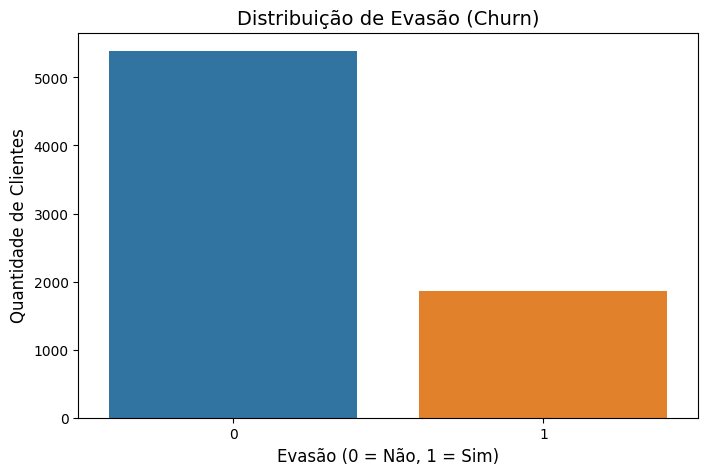

,proportion
evasao,
0,74.0
1,26.0


In [75]:
# Verificação da Proporção de Evasão
# 1. Cria o gráfico de barras
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='evasao', data=df_preparacao, palette='tab10')

# 2. Adiciona título e rótulos
plt.title('Distribuição de Evasão (Churn)', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

plt.show()

round(df_preparacao['evasao'].value_counts(normalize=True) * 100)

In [76]:
# Normalização
# 1. Lista de colunas numéricas que precisam de escala
colunas_para_escalar = ['meses_contrato', 'valor_mensal', 'valor_total']

# 2. Inicializando o Scaler
scaler = StandardScaler()

# 3. Aplicando a transformação
# manter o df_preparacao original intacto para consultas
df_processado = df_preparacao.copy()
df_processado[colunas_para_escalar] = scaler.fit_transform(df_processado[colunas_para_escalar])

# 4. Conferindo a média (deve ser próxima de 0) e o desvio padrão (deve ser 1)
df_processado[colunas_para_escalar].describe().round(2)

,meses_contrato,valor_mensal,valor_total
count,7256.00,7256.00,7256.00
mean,0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.28,-1.54,-1.00
25%,-0.95,-0.97,-0.83
50%,-0.14,0.18,-0.39
75%,0.92,0.83,0.66
max,1.61,1.79,2.82


###4. 🎯 Correlação e Seleção de Variáveis

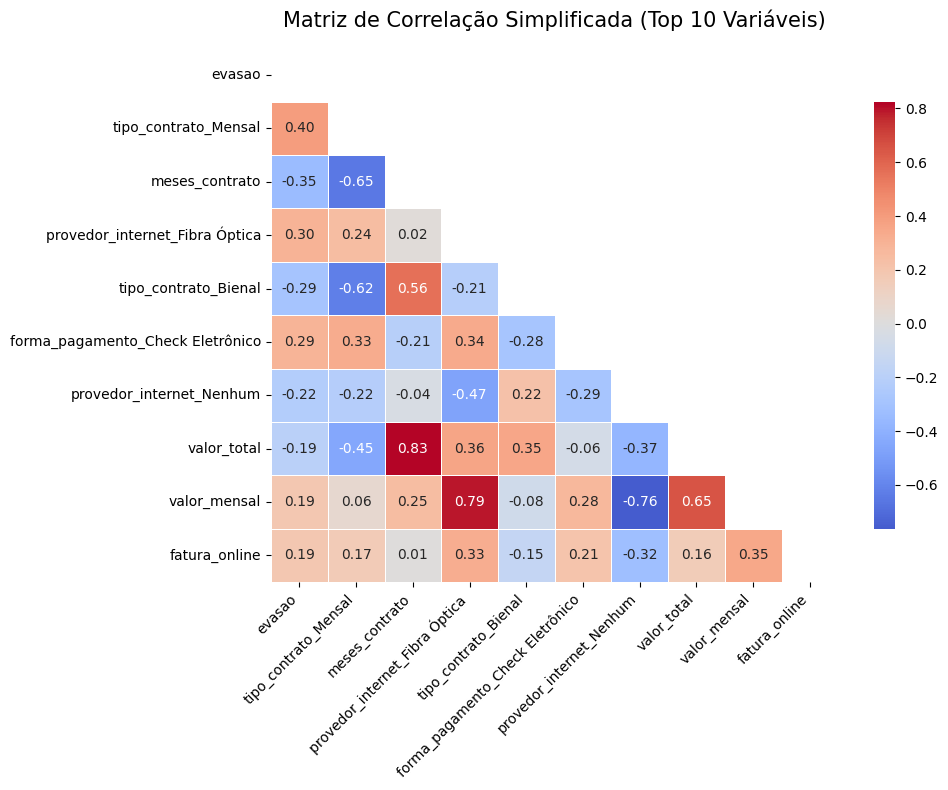

In [77]:
# Análise de Correlação
#1. Identificando as 10 colunas com maior correlação ABSOLUTA com a 'evasao'
# Usamos abs() para pegar tanto as correlações fortes positivas quanto as negativas
top_variaveis = df_processado.corr()['evasao'].abs().sort_values(ascending=False).head(10).index

# 2. Criando a matriz de correlação apenas com essas top 10 variáveis
corr_simplificada = df_processado[top_variaveis].corr()

# 3. Configurando a visualização
plt.figure(figsize=(10, 8))

# Criando a máscara para esconder a parte superior repetida do triângulo
mask = np.triu(np.ones_like(corr_simplificada, dtype=bool))

# Plotando o Heatmap
sns.heatmap(corr_simplificada,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação Simplificada (Top 10 Variáveis)', size=15, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

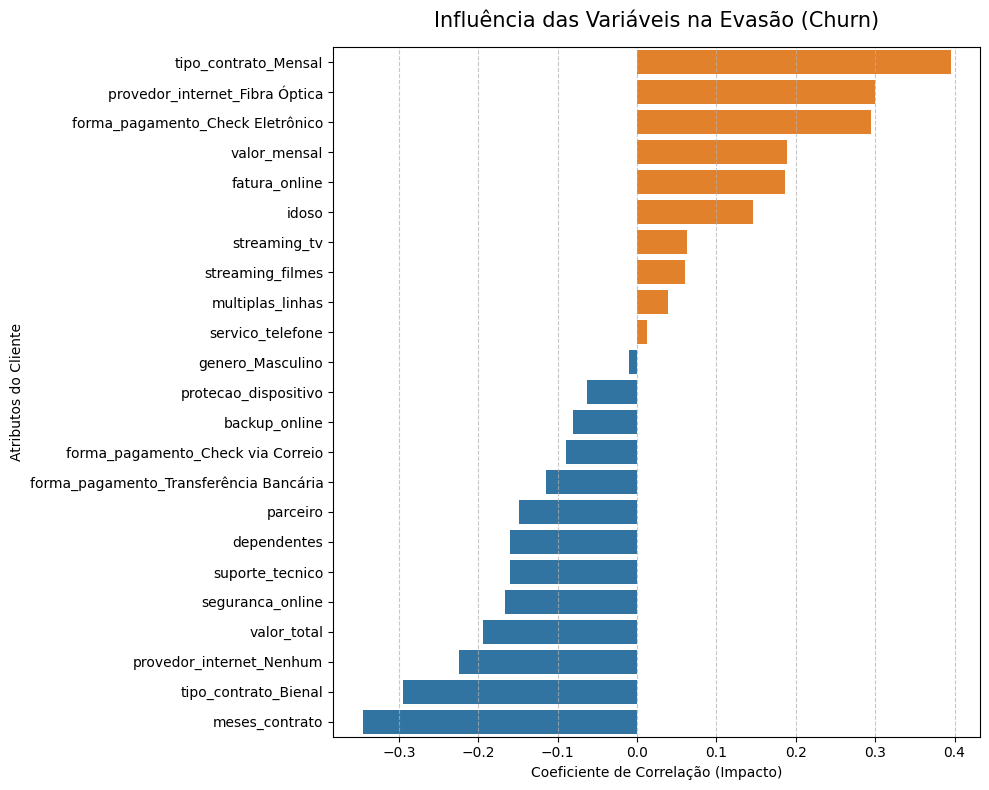

In [78]:
# Análise de Correlação
# 1. Calculando a correlação específica com o alvo
corr_evasao = df_processado.corr()['evasao'].drop('evasao').sort_values(ascending=False)

# 2. Plotando o ranking de influência
plt.figure(figsize=(10, 8))
colors = ['tab:orange' if x > 0 else 'tab:blue' for x in corr_evasao] # AQUA para positiva, CINZA para negativa

sns.barplot(x=corr_evasao.values, y=corr_evasao.index, palette=colors)

plt.title('Influência das Variáveis na Evasão (Churn)', size=15, pad=15)
plt.xlabel('Coeficiente de Correlação (Impacto)')
plt.ylabel('Atributos do Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

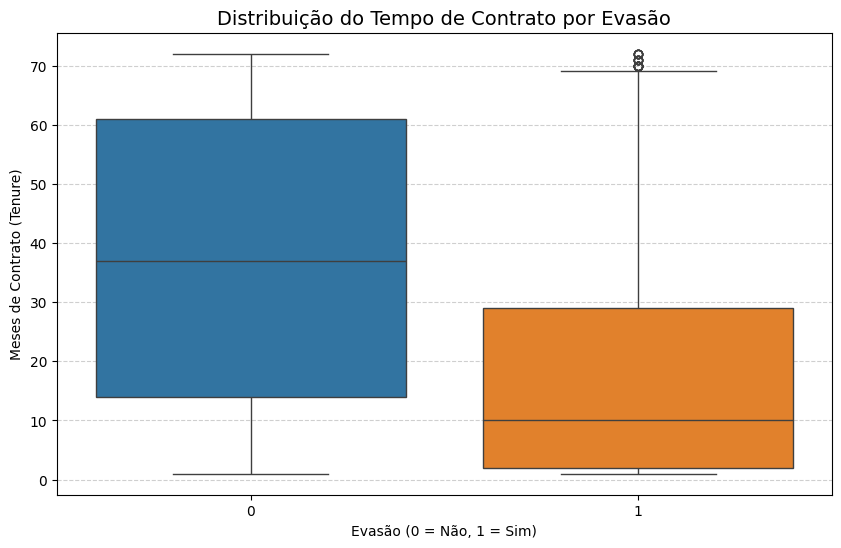

In [79]:
# Análises Direcionadas
#Tempo de Contrato (meses_contrato) × Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(x='evasao', y='meses_contrato', data=df, palette='tab10', hue='evasao', legend=False)

plt.title('Distribuição do Tempo de Contrato por Evasão', size=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato (Tenure)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

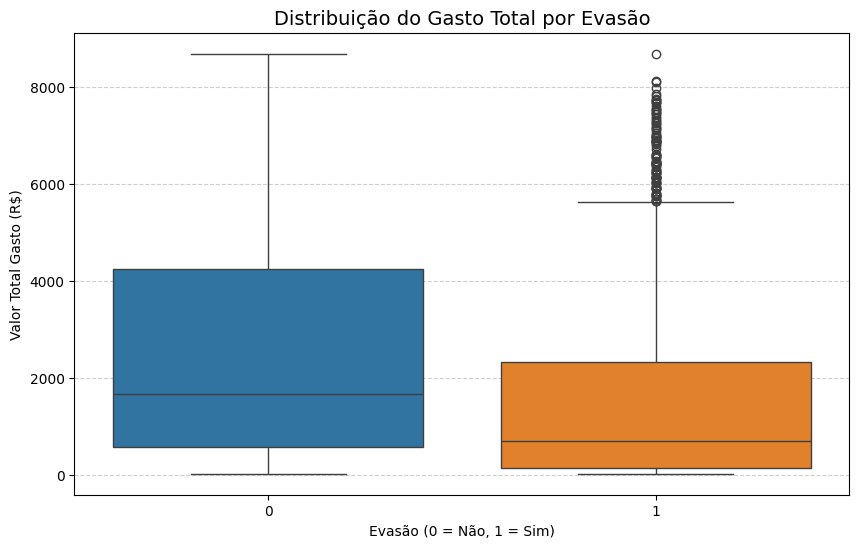

In [80]:
# Análises Direcionadas
# Valor Total (valor_total) × Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(x='evasao', y='valor_total', data=df, palette='tab10', hue='evasao', legend=False)

plt.title('Distribuição do Gasto Total por Evasão', size=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Valor Total Gasto (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

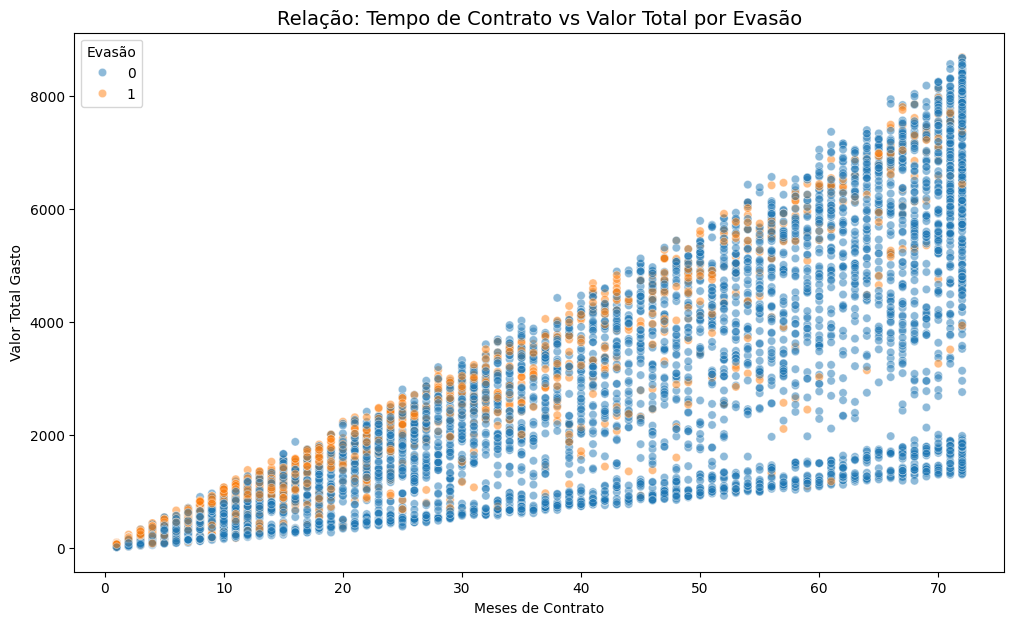

In [81]:
# Análises Direcionadas
# Visualização de Tendência: Dispersão (Scatter Plot)
plt.figure(figsize=(12, 7))
sns.scatterplot(x='meses_contrato', y='valor_total', hue='evasao', data=df, alpha=0.5, palette='tab10')

plt.title('Relação: Tempo de Contrato vs Valor Total por Evasão', size=14)
plt.xlabel('Meses de Contrato')
plt.ylabel('Valor Total Gasto')
plt.legend(title='Evasão', loc='upper left')
plt.show()

###5. 🤖 Modelagem Preditiva

In [82]:
# 1. Seleção de variáveis baseada na análise de correlação
# Removemos o alvo, o ID e as variáveis de baixo impacto/alta colinearidade
X = df_processado.drop(columns=['evasao', 'genero_Masculino', 'servico_telefone', 'valor_total'])
y = df_processado['evasao']

# 2. Divisão entre Treino e Teste (80/20) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Padronização (Scaler)
# Importante: fit apenas no treino para evitar vazamento de dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Balanceamento com SMOTE (Apenas no conjunto de treino)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Dados prontos!")
print(f"Treino balanceado: {X_train_res.shape[0]} amostras (50% churn / 50% retenção)")
print(f"Teste original: {X_test_scaled.shape[0]} amostras (preservando a realidade do negócio)")

Dados prontos!
Treino balanceado: 8618 amostras (50% churn / 50% retenção)
Teste original: 1452 amostras (preservando a realidade do negócio)


####Modelo 1: Regressão Logística (Requer Normalização)
Justificativa: É o modelo clássico para problemas de classificação binária (Churn vs. Não Churn). Ele é rápido, interpretável e fornece a probabilidade de um evento ocorrer.
Necessidade de Normalização: Como a Regressão Logística utiliza o gradiente descendente para encontrar os melhores coeficientes, variáveis com escalas muito diferentes (como meses_contrato vs. valor_mensal) podem fazer com que o modelo demore a convergir ou dê importância indevida a números maiores, em vez de padrões reais.

In [83]:
# --- MODELO 1: REGRESSÃO LOGÍSTICA ---
# Usamos os dados escalonados (X_train_res) pois este modelo é sensível à escala
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_res, y_train_res)

# Predições para avaliação
y_pred_log = log_model.predict(X_test_scaled)

####Modelo 2: Random Forest (Não exige Normalização)
Justificativa: É um modelo de aprendizado por conjunto (ensemble) que cria várias árvores de decisão. Ele é excelente para lidar com dados categóricos codificados e é muito robusto contra overfitting.
Sensibilidade à Escala: Modelos baseados em árvores não calculam distâncias ou gradientes. Eles fazem "cortes" nos dados (ex: meses_contrato > 10). Por isso, a escala original não altera a eficácia do corte, tornando a normalização opcional (embora usá-la não prejudique o modelo).

In [84]:
# --- MODELO 2: RANDOM FOREST ---
# Embora não precise de escala, usaremos os mesmos dados para manter a consistência
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Predições para avaliação
y_pred_rf = rf_model.predict(X_test_scaled)

In [85]:
# --- COMPARANDO RESULTADOS ---
print("="*30)
print("PERFORMANCE: REGRESSÃO LOGÍSTICA")
print(classification_report(y_test, y_pred_log))

print("\n" + "="*30)
print("PERFORMANCE: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

PERFORMANCE: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1078
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1452
   macro avg       0.71      0.76      0.72      1452
weighted avg       0.81      0.75      0.77      1452


PERFORMANCE: RANDOM FOREST
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1078
           1       0.56      0.56      0.56       374

    accuracy                           0.77      1452
   macro avg       0.70      0.70      0.70      1452
weighted avg       0.77      0.77      0.77      1452



--- Métricas: Regressão Logística ---
Acurácia:  0.75
Precisão:  0.51
Recall:    0.79
F1-Score:  0.62

--- Métricas: Random Forest ---
Acurácia:  0.77
Precisão:  0.56
Recall:    0.56
F1-Score:  0.56



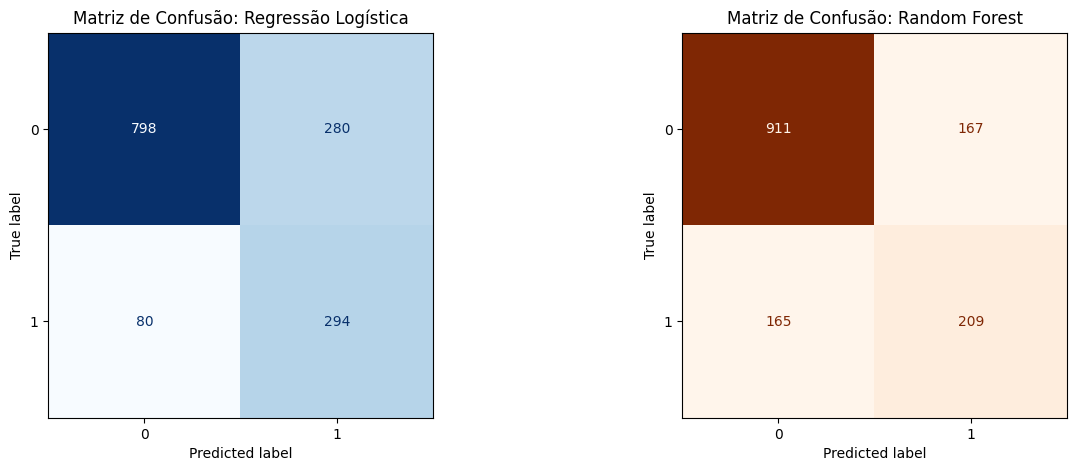

In [86]:
def avaliar_modelo(nome, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- Métricas: {nome} ---")
    print(f"Acurácia:  {acc:.2f}")
    print(f"Precisão:  {prec:.2f}")
    print(f"Recall:    {rec:.2f}")
    print(f"F1-Score:  {f1:.2f}\n")

    return [acc, prec, rec, f1]

# Avaliando os dois modelos
metricas_log = avaliar_modelo("Regressão Logística", y_test, y_pred_log)
metricas_rf = avaliar_modelo("Random Forest", y_test, y_pred_rf)

# Plotando as Matrizes de Confusão Lado a Lado
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matriz de Confusão: Regressão Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Oranges', colorbar=False)
ax[1].set_title('Matriz de Confusão: Random Forest')

plt.show()

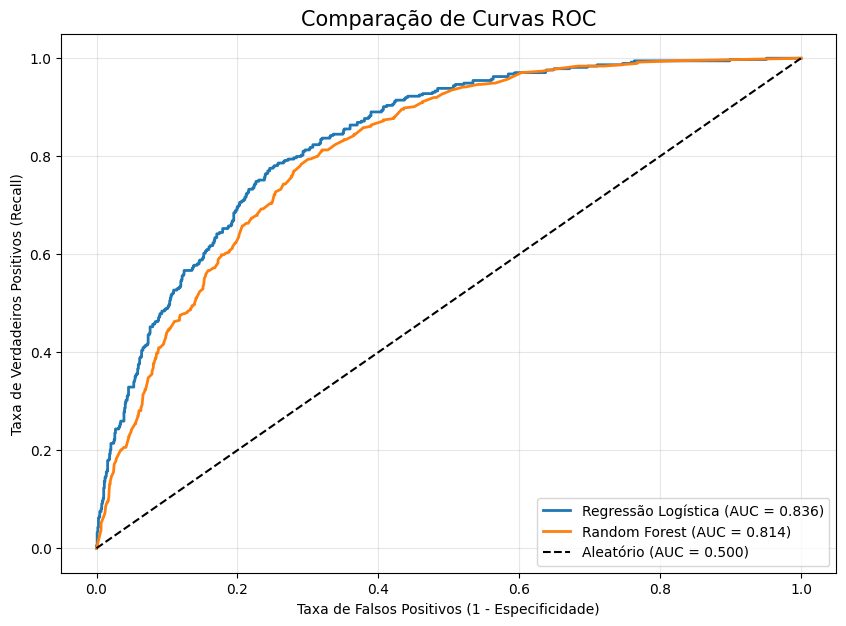

In [87]:
# 1. Calculando as probabilidades de churn (classe 1)
y_probs_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_probs_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calculando a pontuação AUC
auc_log = roc_auc_score(y_test, y_probs_log)
auc_rf = roc_auc_score(y_test, y_probs_rf)

# 3. Gerando os dados da curva
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)

# 4. Plotando o gráfico comparativo
plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {auc_log:.3f})', color='tab:blue', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='tab:orange', lw=2)

# Linha de base (aleatória)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')

plt.title('Comparação de Curvas ROC', size=15)
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [88]:
# Criando um dicionário com os resultados
resultados = {
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Regressão Logística': [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log),
        auc_log
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        auc_rf
    ]
}

# Transformando em DataFrame para melhor visualização
df_metricas = pd.DataFrame(resultados)

# Formatando para duas casas decimais
display(df_metricas.style.format(precision=3).background_gradient(axis=1))

,Métrica,Regressão Logística,Random Forest
0,Acurácia,0.752,0.771
1,Precisão,0.512,0.556
2,Recall,0.786,0.559
3,F1-Score,0.620,0.557
4,AUC-ROC,0.836,0.814


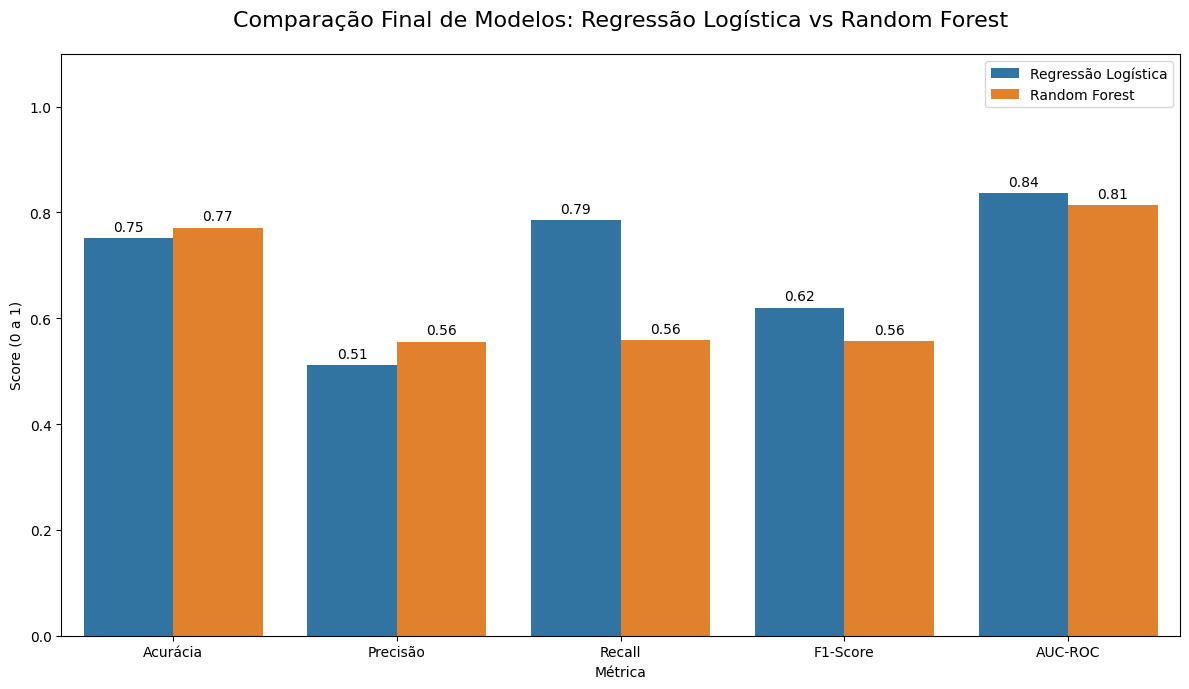

In [89]:
# Preparando os dados para o gráfico (formato longo)
df_plot = df_metricas.melt(id_vars='Métrica', var_name='Modelo', value_name='Valor')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Modelo', palette='tab10')

plt.title('Comparação Final de Modelos: Regressão Logística vs Random Forest', size=16, pad=20)
plt.ylim(0, 1.1)
plt.ylabel('Score (0 a 1)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Adicionar rótulos
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.grid(False)
plt.show()

###6. 📋  Interpretação e Conclusões

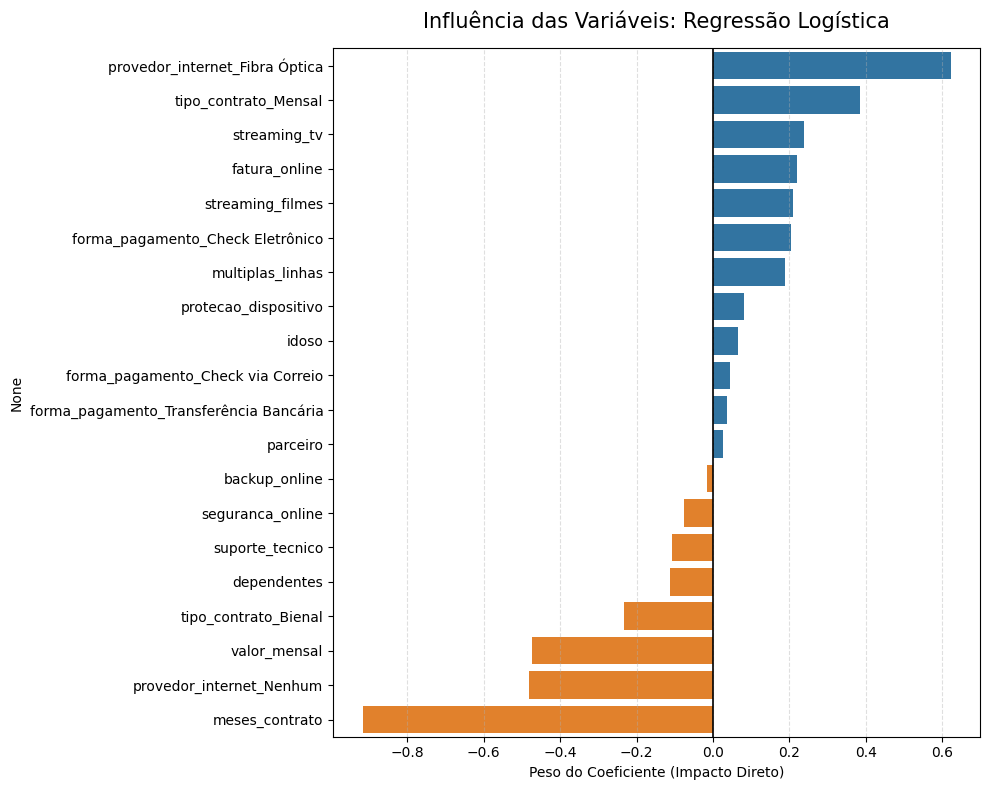

In [90]:
# Análise de Importância das Variáveis
# Extraindo e ordenando os coeficientes
importancia_log = pd.Series(log_model.coef_[0], index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
# Usando a lógica de cores que você prefere (tab:blue e tab:orange)
cores_log = ['tab:blue' if x > 0 else 'tab:orange' for x in importancia_log]

sns.barplot(x=importancia_log.values, y=importancia_log.index, palette=cores_log, hue=importancia_log.index, legend=False)

plt.title('Influência das Variáveis: Regressão Logística', size=15, pad=15)
plt.xlabel('Peso do Coeficiente (Impacto Direto)')
plt.axvline(x=0, color='black', lw=1.2)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

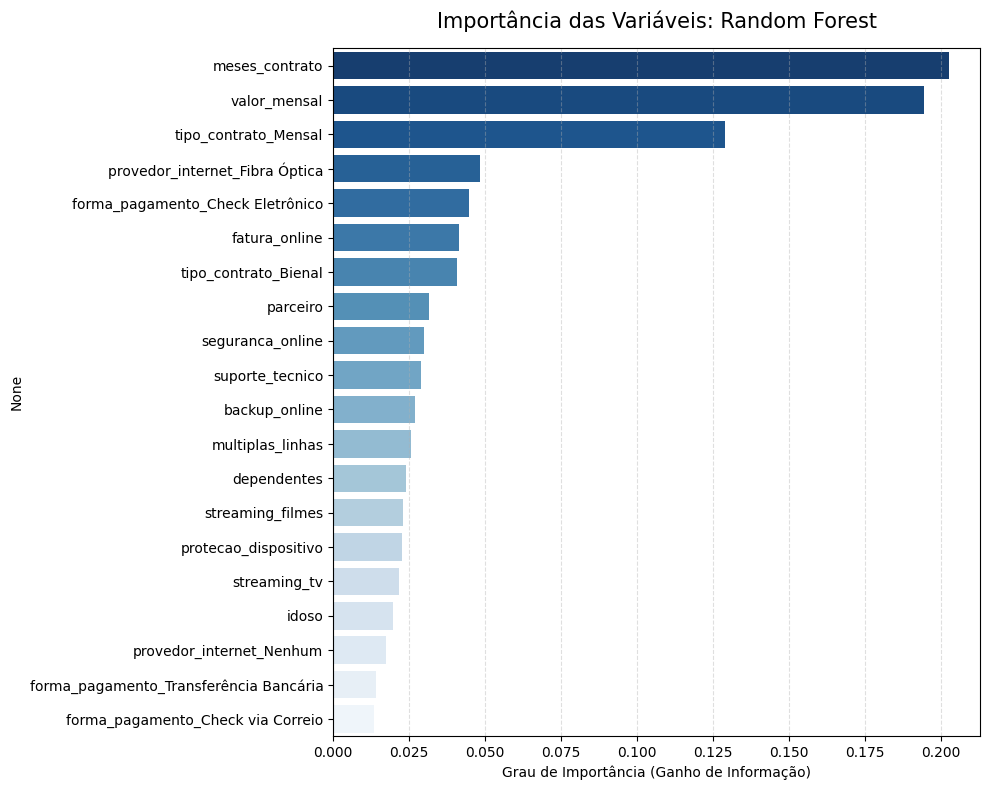

In [91]:
# Análise de Importância das Variáveis
# Extraindo a importância (Feature Importance)
importancia_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
# Usando um degradê de azul para manter a identidade visual limpa
sns.barplot(x=importancia_rf.values, y=importancia_rf.index, palette='Blues_r', hue=importancia_rf.index, legend=False)

plt.title('Importância das Variáveis: Random Forest', size=15, pad=15)
plt.xlabel('Grau de Importância (Ganho de Informação)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 📊 Relatório Analítico – Previsão de Evasão de Clientes (Churn)

## Projeto
Telecom X – Machine Learning para Previsão de Evasão de Clientes

## Objetivo
O objetivo deste projeto é identificar os fatores que mais influenciam a evasão de clientes (churn) e desenvolver modelos de Machine Learning capazes de prever quais clientes possuem maior probabilidade de cancelar seus serviços.

A partir dessa análise, também são propostas estratégias de retenção baseadas nos padrões identificados nos dados.

---

# 1. Contexto do Problema

A evasão de clientes representa um dos principais desafios para empresas de telecomunicações. A perda de clientes impacta diretamente a receita e aumenta os custos de aquisição de novos consumidores.

Dessa forma, identificar **clientes com alto risco de churn** permite que a empresa implemente ações preventivas de retenção.

Neste projeto foram utilizados dois modelos de Machine Learning:

- Regressão Logística
- Random Forest

O objetivo foi comparar o desempenho dos modelos e identificar quais variáveis possuem maior influência na evasão.

---

# 2. Preparação e Tratamento dos Dados

Antes da construção dos modelos, foram realizadas etapas de limpeza e preparação dos dados.

## Remoção de Variáveis Irrelevantes

Algumas variáveis foram removidas por não contribuírem para a modelagem ou apresentarem redundância:

- `id_cliente`
- `valor_diario`

A variável `valor_diario` foi removida devido à alta correlação com `valor_mensal`.

---

## Transformação de Variáveis Categóricas

Variáveis categóricas foram transformadas utilizando **One Hot Encoding**, permitindo que os algoritmos de Machine Learning interpretassem corretamente essas informações.

---

## Normalização de Variáveis Numéricas

Para garantir melhor desempenho do modelo de Regressão Logística, foi aplicada normalização nas seguintes variáveis:

- `meses_contrato`
- `valor_mensal`
- `valor_total`

---

## Balanceamento das Classes

Como o problema de churn normalmente apresenta **desbalanceamento entre clientes que evadem e os que permanecem**, foi aplicado **oversampling (SMOTE)** para equilibrar as classes.

Esse processo evita que o modelo fique enviesado para a classe majoritária.

---

# 3. Análise Exploratória dos Dados

A análise exploratória permitiu identificar padrões iniciais associados à evasão de clientes.

A análise de correlação revelou que algumas variáveis apresentam maior relação com o churn.

## Principais padrões observados

- Clientes com **menos tempo de contrato** apresentam maior probabilidade de evasão.
- Clientes com **maior valor mensal** apresentam maior tendência de cancelamento.
- Clientes com **baixo valor total gasto** tendem a evadir com mais frequência.
- Contratos **mensais** possuem maior taxa de evasão em comparação a contratos de longo prazo.

Esses padrões indicam que o comportamento de churn está fortemente ligado ao **tempo de relacionamento e ao custo percebido do serviço**.

---

# 4. Modelagem Preditiva

Foram treinados dois modelos de classificação para prever a evasão de clientes.

---

# 4.1 Regressão Logística

A Regressão Logística é um modelo amplamente utilizado em problemas de classificação binária.

### Vantagens

- Alta interpretabilidade
- Fácil compreensão para áreas de negócio
- Permite avaliar o impacto de cada variável na probabilidade de churn

Os coeficientes do modelo indicam quais variáveis aumentam ou reduzem a probabilidade de evasão.

---

# 4.2 Random Forest

O Random Forest é um modelo baseado em múltiplas árvores de decisão.

### Vantagens

- Capacidade de capturar relações não lineares
- Robustez contra ruídos nos dados
- Melhor desempenho preditivo em muitos cenários

Esse modelo também fornece métricas de **importância das variáveis (Feature Importance)**, permitindo identificar quais fatores mais influenciam as previsões.

---

# 5. Avaliação dos Modelos

Os modelos foram avaliados utilizando as seguintes métricas:

- **Acurácia**
- **Precisão**
- **Recall**
- **F1-score**
- **AUC-ROC**

## Interpretação das Métricas

| Métrica | Significado |
|------|------|
| Acurácia | Proporção total de previsões corretas |
| Precisão | Percentual de clientes previstos como churn que realmente evadiram |
| Recall | Capacidade do modelo de identificar clientes que realmente irão evadir |
| F1-score | Equilíbrio entre precisão e recall |
| AUC-ROC | Capacidade do modelo de separar corretamente churn e não churn |

De forma geral:

- **Random Forest apresentou melhor desempenho preditivo**
- **Regressão Logística apresentou maior interpretabilidade**

---

# 6. Principais Fatores que Influenciam a Evasão

Com base na análise dos modelos e na correlação entre variáveis, os fatores mais relevantes para churn são:

## Tempo de contrato

Clientes com menor tempo de relacionamento possuem maior probabilidade de evasão.

Isso indica que os **primeiros meses são críticos para retenção**.

---

## Valor mensal do plano

Clientes com planos mais caros tendem a apresentar maior risco de cancelamento.

Esse fator pode estar relacionado à **percepção de custo elevado ou concorrência com preços menores**.

---

## Valor total gasto

Clientes que possuem baixo valor acumulado gasto apresentam menor fidelização.

Isso geralmente indica clientes **recentes ou com baixo engajamento no serviço**.

---

## Tipo de contrato

Clientes com contratos **mensais** apresentam maior probabilidade de churn.

Contratos de longo prazo criam **maior compromisso e fidelização**.

---

# 7. Estratégias de Retenção Baseadas nos Resultados

Com base nos fatores identificados, algumas estratégias podem ser adotadas para reduzir a evasão.

---

## Programa de retenção para novos clientes

Como o churn é maior nos primeiros meses, a empresa pode implementar:

- acompanhamento nos primeiros 90 dias
- suporte dedicado para novos clientes
- benefícios iniciais

Exemplo:

- descontos temporários
- onboarding estruturado

---

## Incentivo a contratos de longo prazo

Para reduzir churn, a empresa pode estimular contratos mais longos:

- descontos em planos anuais
- bônus de fidelidade
- upgrades de serviço

---

## Ajuste da percepção de preço

Clientes com planos mais caros podem cancelar por percepção de custo elevado.

Estratégias possíveis:

- revisão de pacotes
- inclusão de benefícios adicionais
- personalização de planos

---

## Segmentação de clientes com risco de churn

Os modelos desenvolvidos podem ser utilizados para identificar clientes com alta probabilidade de evasão.

A partir disso, a empresa pode:

- priorizar ações de retenção
- oferecer ofertas personalizadas
- realizar contato proativo com clientes de risco.

---

# 8. Conclusão

A aplicação de técnicas de Machine Learning permitiu identificar fatores relevantes associados à evasão de clientes na Telecom X.

Os principais fatores identificados foram:

- tempo de contrato
- valor mensal do plano
- valor total gasto
- tipo de contrato

Entre os modelos testados:

- **Random Forest apresentou melhor desempenho preditivo**
- **Regressão Logística apresentou maior capacidade de interpretação dos fatores**

A utilização desses modelos permite que a empresa implemente estratégias proativas de retenção, reduzindo o churn e aumentando o valor do cliente ao longo do tempo.

A integração entre **análise de dados, Machine Learning e estratégias de negócio** pode gerar vantagem competitiva significativa para a organização.